<font color='blue'>  **5a _______________________ Mass and Momentum  _______________** </font> <br>

In [1]:
from Grid import Grid  ;from ScalarCoeffs import ScalarCoeffs ;from BoundaryConditions import BoundaryLocation, DirichletBc, NeumannBc ;from LinearSolver import solve 
from Models import DiffusionModel, SurfaceConvectionModel, FirstOrderTransientModel, PressureForceModel , AdvectingVelocityModel , MassConservationEquation, UpwindAdvectionModel
%matplotlib inline
import matplotlib.pyplot as plt ;import numpy as np  ;from numpy.linalg import norm   

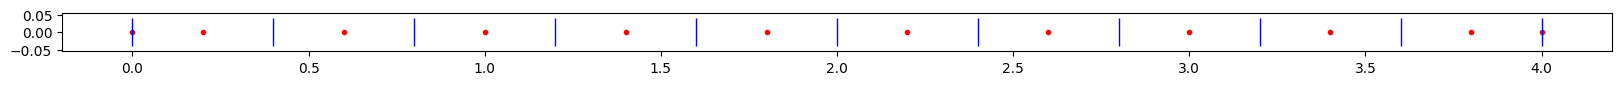

In [2]:
lx = 4.0 ;ly = 0.02 ;lz = 0.01 ;ncv = 10       ;grid = Grid(lx, ly, lz, ncv)            ;nTime = 1 ;dt = 1e9 ;time = 0  
maxIter = 100 ;converged = 1e-6                ;rho = 1000 ;cp = 4000 ;k = 0.5          ;ho = 50   ;To = 200 ;mu = 1e-3     

fig, ax = plt.subplots(figsize=(20, 0.5))       #;ax.set_xlim(grid.xf[0], grid.xf[int(len(grid.xf))-1])
ax.plot  (grid.xP, np.zeros_like(grid.xP), 'o',markersize=3,color='red')     ;ax.plot  (grid.xf, np.zeros_like(grid.xf), '|', markersize=20,color='b')      ;plt.show()

In [3]:
PU_coeffs = ScalarCoeffs(grid.ncv)   ;PP_coeffs = ScalarCoeffs(grid.ncv)    ;UP_coeffs = ScalarCoeffs(grid.ncv) ;UU_coeffs = ScalarCoeffs(grid.ncv)
U0 = 10 ;U = U0*np.ones(grid.ncv+2)  ;Uold = np.copy(U)                     ;P0 = 0  ;P = P0*np.ones(grid.ncv+2)
dhat = np.zeros(grid.ncv+1)          ;Uhe = U0*np.ones(grid.ncv+1)      # Advecting velocity and damping coefficient   #P_west_bc = ExtrapolatedBc(P, grid, BoundaryLocation.WEST)

U_west_bc = DirichletBc(U, grid, U0 ,BoundaryLocation.WEST) ;U_east_bc = NeumannBc  (U, grid, 0, BoundaryLocation.EAST)  ;U_west_bc.apply() ;U_east_bc.apply()
P_west_bc = NeumannBc  (P, grid, 0  ,BoundaryLocation.WEST) ;P_east_bc = DirichletBc(P, grid, 0, BoundaryLocation.EAST)  ;P_west_bc.apply() ;P_east_bc.apply()

transient = FirstOrderTransientModel (grid, U, Uold, rho, 1, dt)                    ;diffusion = DiffusionModel           (grid, U, mu, U_west_bc, U_east_bc)
advection = UpwindAdvectionModel     (grid, U, Uhe, rho, 1, U_west_bc, U_east_bc)   ;pressure  = PressureForceModel(grid, P, P_west_bc, P_east_bc)
advecting = AdvectingVelocityModel(grid, dhat, Uhe, P, U, UU_coeffs)                ;mass      = MassConservationEquation(grid, U, P, dhat, Uhe, rho, P_west_bc, P_east_bc, U_west_bc, U_east_bc)

for tStep in range(nTime):
    time += dt  ;print("Timestep = {};Time = {}".format(tStep, time)) ;Uold[:] = U[:]
    
    for i in range(maxIter):
        PP_coeffs.zero();PU_coeffs.zero()     ;UU_coeffs.zero();UP_coeffs.zero()     
        UU_coeffs = diffusion.add(UU_coeffs)  ;UU_coeffs = advection.add(UU_coeffs)  ;UU_coeffs = transient.add(UU_coeffs)   ;UP_coeffs = pressure.add(UP_coeffs)
        advecting.update()                    ;PP_coeffs, PU_coeffs = mass.add(PP_coeffs, PU_coeffs)

        PmaxResid = norm(PU_coeffs.rP + PP_coeffs.rP, np.inf)   ;PavgResid = np.mean(np.absolute(PU_coeffs.rP + PP_coeffs.rP))
        UmaxResid = norm(UU_coeffs.rP + UP_coeffs.rP, np.inf)   ;UavgResid = np.mean(np.absolute(UU_coeffs.rP + UP_coeffs.rP)) ;print("Iteration = {}.".format(i))
        print("  Mass:     Max. Resid. = {};Avg. Resid. = {}".format(PmaxResid, PavgResid))    ;
        print("  Momentum: Max. Resid. = {};Avg. Resid. = {}".format(UmaxResid, UavgResid))
        if PmaxResid < converged and UmaxResid < converged:      break
    
        dP, dU = solve(PP_coeffs, PU_coeffs, UP_coeffs, UU_coeffs)  ;P[1:-1] += dP ;U[1:-1] += dU  ;U_west_bc.apply();U_east_bc.apply();P_west_bc.apply();P_east_bc.apply()
        advecting.update()

Timestep = 0;Time = 1000000000.0
Iteration = 0.
  Mass:     Max. Resid. = 0.0;Avg. Resid. = 0.0
  Momentum: Max. Resid. = 0.0;Avg. Resid. = 0.0


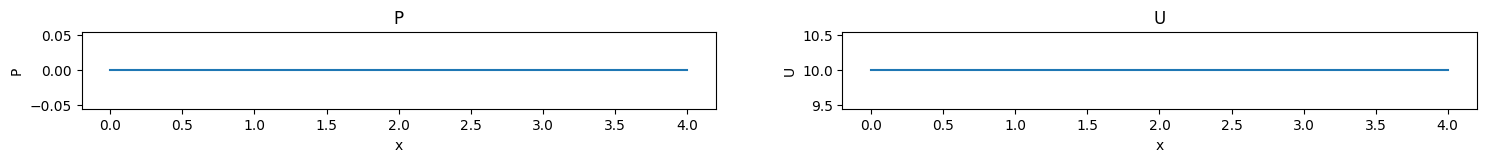

In [4]:
fig = plt.figure(figsize=(18, 1))                                               
ax = fig.add_subplot(121)      ;plt.plot(grid.xP, P) ;plt.xlabel("x") ;plt.ylabel("P")  ;plt.title("P")
ax = fig.add_subplot(122)      ;plt.plot(grid.xP, U) ;plt.xlabel("x") ;plt.ylabel("U")  ;plt.title("U")
plt.show()